# Mobile Money Fraud Detection

**Real-time fraud operations profile for PaySim-style transactions**

This notebook presents a complete HUG-IML model-governance workflow: data and metadata review, interpretable pattern training, performance assessment, rule inventory, threshold behavior, and subgroup monitoring.

## Review orientation

- Focuses on balance-drainage behavior, destination-balance anomalies, high-value transfer patterns, and payment-channel concentration.
- Uses compact operational views suitable for fraud operations and model-risk review.

The objective is not only predictive performance. The workflow emphasizes inspectable decision evidence that can be reviewed by model-risk, audit, compliance, and domain stakeholders.

In [1]:

import os, json, warnings, math
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, HTML, Markdown
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, accuracy_score, precision_recall_fscore_support
)
from hugiml import HUGIMLClassifierNative

RANDOM_STATE = 42
DATA_FILE = 'nb06_mobile_money_fraud_data.csv'
METADATA_FILE = 'nb06_mobile_money_fraud_metadata.csv'
TARGET = 'isFraud'
POSITIVE_LABEL = 'Fraudulent transaction'
GROUP_COLUMNS = ['type', 'is_cash_out', 'is_transfer', 'dest_unchanged', 'origin_near_zero', 'high_value']
MODEL_PARAMS = dict(B=10, L=1, G=1e-4, topK=100)

THEME = {'name': 'Fraud operations console', 'bg': '#130c2a', 'panel': '#211642', 'text': '#f5f1ff', 'muted': '#b9aee7', 'accent': '#00d7ff', 'accent2': '#ff4fd8', 'accent3': '#ffd166', 'grid': '#3b2a68'}

plt.rcParams.update({
    'figure.figsize': (9, 4.8),
    'axes.facecolor': THEME['panel'],
    'figure.facecolor': THEME['bg'],
    'axes.edgecolor': THEME['grid'],
    'axes.labelcolor': THEME['text'],
    'xtick.color': THEME['muted'],
    'ytick.color': THEME['muted'],
    'text.color': THEME['text'],
    'font.size': 10,
    'axes.titleweight': 'bold'
})

display(HTML("""
<style>
:root {
  --bg: #130c2a;
  --panel: #211642;
  --text: #f5f1ff;
  --muted: #b9aee7;
  --accent: #00d7ff;
  --accent2: #ff4fd8;
  --accent3: #ffd166;
  --grid: #3b2a68;
}
.jp-Notebook, body { background: var(--bg) !important; color: var(--text); }
h1, h2, h3 { color: var(--text); letter-spacing: -0.02em; }
h1 { border-bottom: 4px solid var(--accent); padding-bottom: 0.35rem; }
h2 { margin-top: 1.6rem; border-left: 6px solid var(--accent2); padding-left: 0.7rem; }
table { border-collapse: collapse; width: 100%; font-size: 0.92rem; }
th { background: var(--accent); color: white; text-align: left; }
td, th { border: 1px solid var(--grid); padding: 0.48rem 0.55rem; }
tr:nth-child(even) { background: rgba(127,127,127,0.06); }
.gov-card-grid { display: grid; grid-template-columns: repeat(4, minmax(0,1fr)); gap: 0.9rem; margin: 0.8rem 0 1.0rem; }
.gov-card { background: var(--panel); border: 1px solid var(--grid); border-radius: 16px; padding: 0.9rem 1rem; box-shadow: 0 7px 22px rgba(0,0,0,0.08); }
.gov-card .label { color: var(--muted); font-size: 0.78rem; text-transform: uppercase; letter-spacing: 0.06em; }
.gov-card .value { color: var(--accent); font-size: 1.55rem; font-weight: 800; margin-top: 0.2rem; }
.gov-card .note { color: var(--muted); font-size: 0.82rem; margin-top: 0.25rem; }
.callout { background: linear-gradient(135deg, var(--panel), rgba(127,127,127,0.06)); border-left: 6px solid var(--accent3); padding: 0.8rem 1rem; border-radius: 12px; margin: 1rem 0; }
.small-note { color: var(--muted); font-size: 0.9rem; }
</style>
"""))


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-fi6iva6u because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


## Dataset and metadata review

In [2]:

df = pd.read_csv(DATA_FILE)
metadata = pd.read_csv(METADATA_FILE)

target_rate = df[TARGET].mean()
n_rows, n_cols = df.shape
feature_count = n_cols - 1
numeric_features = df.drop(columns=[TARGET]).select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in df.drop(columns=[TARGET]).columns if c not in numeric_features]

missing_cells = int(df.isna().sum().sum())
duplicate_rows = int(df.duplicated().sum())

display(HTML(f'''
<div class="gov-card-grid">
  <div class="gov-card"><div class="label">Rows</div><div class="value">{n_rows:,}</div><div class="note">Modeling population</div></div>
  <div class="gov-card"><div class="label">Candidate features</div><div class="value">{feature_count}</div><div class="note">{len(numeric_features)} numeric, {len(categorical_features)} categorical</div></div>
  <div class="gov-card"><div class="label">Positive class rate</div><div class="value">{target_rate:.2%}</div><div class="note">{POSITIVE_LABEL}</div></div>
  <div class="gov-card"><div class="label">Data checks</div><div class="value">{missing_cells}</div><div class="note">Missing cells; {duplicate_rows:,} duplicate rows</div></div>
</div>
'''))

display(Markdown("### Data sample"))
display(df.head(8))
display(Markdown("### Metadata register"))
display(metadata[['column_name','data_type','description','role','importance','notes']].head(20))


### Data sample

,type,amount,oldbalanceOrg,oldbalanceDest,newbalanceOrig,newbalanceDest,isFraud,balance_change_orig,balance_change_dest,amount_to_balance_ratio,dest_to_amount_ratio,dest_unchanged,origin_near_zero,origin_significant_drop,is_cash_out,is_transfer,high_value,medium_value
0,CASH_OUT,146.155801,4228.030022,31860.983455,4081.874221,31714.827654,0.0,-146.155801,-146.155801,0.034560,-0.993204,0,0,0,1,0,0,0
1,CASH_OUT,655.759571,69.001448,211.799857,0.000000,0.000000,0.0,-69.001448,-211.799857,9.367800,-0.322492,0,1,1,1,0,0,0
2,CASH_IN,293.547115,710336.890252,283.802793,710630.437367,577.349909,0.0,293.547115,293.547115,0.000413,0.996605,0,0,0,0,0,0,0
3,CASH_IN,67.553948,513.561359,617.414728,581.115307,684.968677,0.0,67.553948,67.553948,0.131285,0.985413,1,0,0,0,0,0,0
4,CASH_OUT,1973.691473,274.812049,7743.886521,0.000000,5770.195048,0.0,-274.812049,-1973.691473,7.155929,-0.999494,0,1,1,1,0,0,0
5,CASH_OUT,503.509597,572.296379,291.596973,68.786782,0.000000,0.0,-503.509597,-291.596973,0.878271,-0.577981,0,1,1,1,0,0,0
6,PAYMENT,2086.859009,73974.975405,1611.213942,71888.116395,3698.072951,0.0,-2086.859009,2086.859009,0.028210,0.999521,0,0,0,0,0,0,0
7,CASH_IN,55.184458,50204.647383,15123.329350,50259.831841,15178.513808,0.0,55.184458,55.184458,0.001099,0.982201,1,0,0,0,0,0,0


### Metadata register

,column_name,data_type,description,role,importance,notes
0,type,categorical,Transaction type,feature,High,TRANSFER and CASH_OUT show 10-15x higher fraud...
1,amount,numerical,Transaction amount,feature,High,Large transfers more susceptible to fraud
2,oldbalanceOrg,numerical,Origin account balance before transaction,feature,Critical,Large balances (>$94K) targeted by fraudsters
3,newbalanceOrig,numerical,Origin account balance after transaction,feature,Critical,Near-zero balance (<$369) after large transfer...
4,oldbalanceDest,numerical,Destination account balance before transaction,feature,Critical,Used to detect destination unchanged anomaly
5,newbalanceDest,numerical,Destination account balance after transaction,feature,Critical,Fraudulent transactions often show no destinat...
6,balance_change_orig,numerical,Derived: newbalanceOrig - oldbalanceOrg,feature,High,Large negative changes indicate account drainage
7,balance_change_dest,numerical,Derived: newbalanceDest - oldbalanceDest,feature,Critical,Near-zero change despite transfer is key fraud...
8,amount_to_balance_ratio,numerical,Derived: amount / (oldbalanceOrg + 1),feature,High,High ratios (>0.7) indicate significant accoun...
9,dest_to_amount_ratio,numerical,Derived: balance_change_dest / (amount + 1),feature,Critical,TOP PATTERN: ratio ≠ 1.0 detects balance manip...


## HUG-IML model training and holdout evaluation

In [3]:

MAX_MODEL_ROWS = 50000
if len(df) > MAX_MODEL_ROWS:
    model_df, _ = train_test_split(
        df, train_size=MAX_MODEL_ROWS, random_state=RANDOM_STATE, stratify=df[TARGET].astype(int)
    )
    model_df = model_df.sort_index().reset_index(drop=True)
else:
    model_df = df.copy().reset_index(drop=True)

X = model_df.drop(columns=[TARGET])
y = model_df[TARGET].astype(int)

display(HTML(f'''
<div class="callout">
<b>Modeling population.</b> The dataset review uses all {len(df):,} transactions. 
The HUG-IML governance model below uses a stratified modeling population of {len(model_df):,} transactions to keep this large-scale fraud notebook reproducible while preserving the positive-class rate.
</div>
'''))

clf = HUGIMLClassifierNative(**MODEL_PARAMS)
X_enc, y_enc = clf.prepareXy(X, y)

X_train_enc, X_test_enc, y_train_enc, y_test_enc = train_test_split(
    X_enc, y_enc, test_size=0.30, random_state=RANDOM_STATE, stratify=y_enc
)

clf.fit(X_train_enc, y_train_enc)

y_score = clf.predict_proba(X_test_enc)[:, 1]
auc = roc_auc_score(y_test_enc, y_score)
ap = average_precision_score(y_test_enc, y_score)
patterns = clf.feature_importances().copy()
patterns['direction'] = np.where(patterns['coefficient'] >= 0, 'risk-increasing', 'risk-decreasing')
n_patterns = len(patterns)

fpr, tpr, roc_thresholds = roc_curve(y_test_enc, y_score)
precision, recall, pr_thresholds = precision_recall_curve(y_test_enc, y_score)
youden_idx = int(np.argmax(tpr - fpr))
operating_threshold = float(roc_thresholds[youden_idx])
if not np.isfinite(operating_threshold):
    operating_threshold = 0.50

y_pred = (y_score >= operating_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_enc, y_pred).ravel()
precision_op, recall_op, f1_op, _ = precision_recall_fscore_support(y_test_enc, y_pred, average='binary', zero_division=0)
accuracy_op = accuracy_score(y_test_enc, y_pred)

display(HTML(f'''
<div class="gov-card-grid">
  <div class="gov-card"><div class="label">AUC-ROC</div><div class="value">{auc:.3f}</div><div class="note">Rank separation on holdout</div></div>
  <div class="gov-card"><div class="label">Average precision</div><div class="value">{ap:.3f}</div><div class="note">Positive-class concentration</div></div>
  <div class="gov-card"><div class="label">HUG patterns</div><div class="value">{n_patterns}</div><div class="note">Transparent model evidence</div></div>
  <div class="gov-card"><div class="label">Operating threshold</div><div class="value">{operating_threshold:.3f}</div><div class="note">Youden-index threshold</div></div>
</div>
<div class="callout">
<b>Holdout result.</b> At the selected threshold, precision is <b>{precision_op:.2%}</b>, recall is <b>{recall_op:.2%}</b>, and F1 is <b>{f1_op:.3f}</b>. 
The confusion matrix is TP={tp:,}, FP={fp:,}, TN={tn:,}, FN={fn:,}.
</div>
'''))


## Pattern inventory

The highest-magnitude patterns are the strongest transparent contributors to the model score. Positive coefficients increase the estimated probability of the event; negative coefficients reduce it.

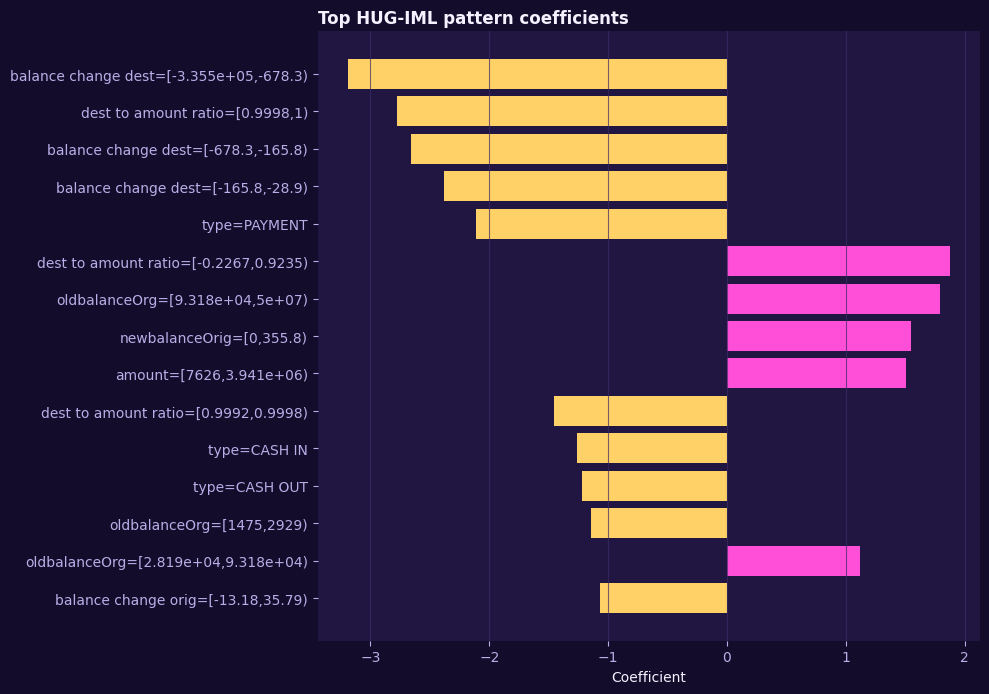

,pattern,coefficient,support,direction
0,"balance_change_dest=[-3.355e+05,-678.3)",-3.190152,0.1000,risk-decreasing
1,"dest_to_amount_ratio=[0.9998,1)",-2.776684,0.1000,risk-decreasing
2,"balance_change_dest=[-678.3,-165.8)",-2.657719,0.1000,risk-decreasing
3,"balance_change_dest=[-165.8,-28.9)",-2.381674,0.1000,risk-decreasing
4,type=PAYMENT,-2.111625,0.3412,risk-decreasing
5,"dest_to_amount_ratio=[-0.2267,0.9235)",1.876955,0.1000,risk-increasing
6,"oldbalanceOrg=[9.318e+04,5e+07)",1.790886,0.1000,risk-increasing
7,"newbalanceOrig=[0,355.8)",1.553405,0.3000,risk-increasing
8,"amount=[7626,3.941e+06)",1.507493,0.1000,risk-increasing
9,"dest_to_amount_ratio=[0.9992,0.9998)",-1.451129,0.1000,risk-decreasing


### Governance feature register

,column_name,data_type,importance,pattern_count,modeled_signal,notes
0,dest_to_amount_ratio,numerical,Critical,10,present in HUG patterns,TOP PATTERN: ratio ≠ 1.0 detects balance manip...
1,oldbalanceOrg,numerical,Critical,7,present in HUG patterns,Large balances (>$94K) targeted by fraudsters
2,balance_change_dest,numerical,Critical,6,present in HUG patterns,Near-zero change despite transfer is key fraud...
3,newbalanceOrig,numerical,Critical,5,present in HUG patterns,Near-zero balance (<$369) after large transfer...
4,oldbalanceDest,numerical,Critical,0,not selected directly,Used to detect destination unchanged anomaly
5,newbalanceDest,numerical,Critical,0,not selected directly,Fraudulent transactions often show no destinat...
6,dest_unchanged,binary,Critical,0,not selected directly,Destination unchanged despite transfer is frau...
7,balance_change_orig,numerical,High,8,present in HUG patterns,Large negative changes indicate account drainage
8,amount,numerical,High,7,present in HUG patterns,Large transfers more susceptible to fraud
9,type,categorical,High,4,present in HUG patterns,TRANSFER and CASH_OUT show 10-15x higher fraud...


In [4]:

def styled_barh(data, x, y, title, xlabel, color_col=None, limit=12):
    plot_df = data.head(limit).copy()
    fig, ax = plt.subplots(figsize=(10, max(4.8, 0.35 * len(plot_df) + 1.8)))
    colors = [THEME['accent2'] if v >= 0 else THEME['accent3'] for v in plot_df[color_col]] if color_col else THEME['accent']
    ax.barh(plot_df[y], plot_df[x], color=colors)
    ax.invert_yaxis()
    ax.set_title(title, loc='left')
    ax.set_xlabel(xlabel)
    ax.grid(axis='x', color=THEME['grid'], alpha=0.7)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()

top_patterns = patterns.sort_values('abs_coefficient', ascending=False).head(15).copy()
top_patterns['display_pattern'] = top_patterns['pattern'].str.replace('_', ' ', regex=False)
display(Markdown("## Pattern inventory"))
display(Markdown("The highest-magnitude patterns are the strongest transparent contributors to the model score. Positive coefficients increase the estimated probability of the event; negative coefficients reduce it."))
styled_barh(top_patterns, 'coefficient', 'display_pattern', 'Top HUG-IML pattern coefficients', 'Coefficient', color_col='coefficient', limit=15)
display(top_patterns[['pattern','coefficient','support','direction']].reset_index(drop=True))

# Metadata alignment
feature_rows = metadata[metadata['role'].str.lower().eq('feature')].copy() if 'role' in metadata.columns else metadata.copy()
def feature_in_patterns(feature):
    return int(patterns['pattern'].astype(str).str.startswith(str(feature) + '=').sum() + patterns['pattern'].astype(str).str.startswith(str(feature) + '[').sum())
feature_rows['pattern_count'] = feature_rows['column_name'].map(feature_in_patterns)
feature_rows['modeled_signal'] = np.where(feature_rows['pattern_count'] > 0, 'present in HUG patterns', 'not selected directly')
feature_rows = feature_rows.sort_values(['importance','pattern_count'], ascending=[True, False])
display(Markdown("### Governance feature register"))
display(feature_rows[['column_name','data_type','importance','pattern_count','modeled_signal','notes']].reset_index(drop=True))


## Discrimination and threshold behavior

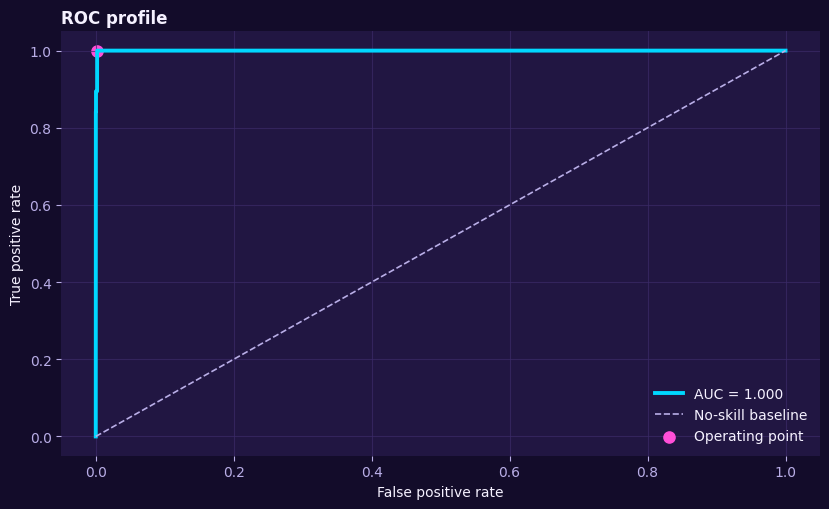

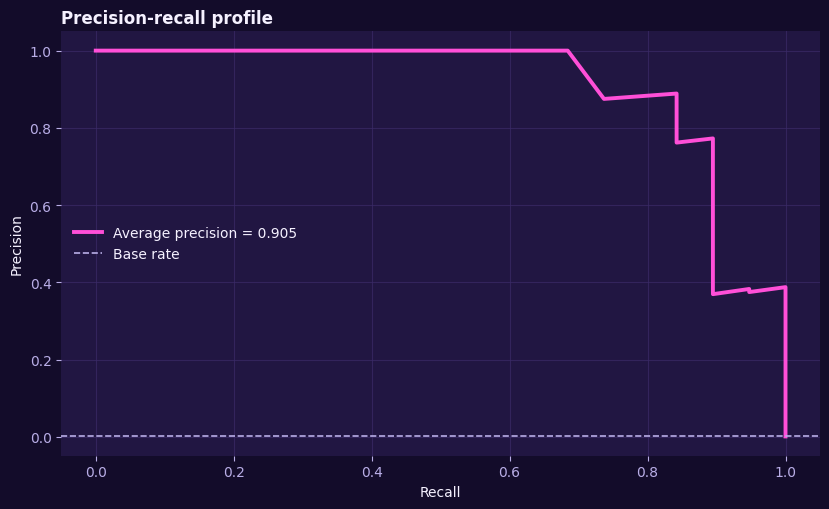

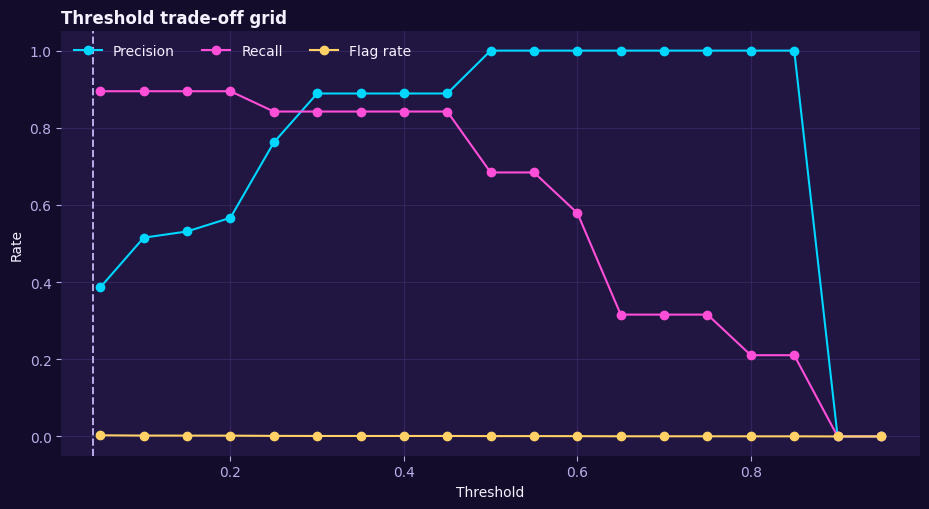

,threshold,precision,recall,f1,flag_rate,false_positive_rate
0,0.05,0.3864,0.8947,0.5397,0.0029,0.0018
1,0.10,0.5152,0.8947,0.6538,0.0022,0.0011
2,0.15,0.5312,0.8947,0.6667,0.0021,0.0010
3,0.20,0.5667,0.8947,0.6939,0.0020,0.0009
4,0.25,0.7619,0.8421,0.8000,0.0014,0.0003
5,0.30,0.8889,0.8421,0.8649,0.0012,0.0001
6,0.35,0.8889,0.8421,0.8649,0.0012,0.0001
7,0.40,0.8889,0.8421,0.8649,0.0012,0.0001
8,0.45,0.8889,0.8421,0.8649,0.0012,0.0001
9,0.50,1.0000,0.6842,0.8125,0.0009,0.0000


In [5]:

display(Markdown("## Discrimination and threshold behavior"))

fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.plot(fpr, tpr, linewidth=2.8, color=THEME['accent'], label=f'AUC = {auc:.3f}')
ax.plot([0, 1], [0, 1], linestyle='--', linewidth=1.2, color=THEME['muted'], label='No-skill baseline')
ax.scatter([fpr[youden_idx]], [tpr[youden_idx]], s=65, color=THEME['accent2'], label='Operating point')
ax.set_title('ROC profile', loc='left')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.grid(color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8.4, 5.2))
ax.plot(recall, precision, linewidth=2.8, color=THEME['accent2'], label=f'Average precision = {ap:.3f}')
ax.axhline(y_test_enc.mean(), linestyle='--', linewidth=1.2, color=THEME['muted'], label='Base rate')
ax.set_title('Precision-recall profile', loc='left')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.grid(color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

threshold_grid = np.linspace(0.05, 0.95, 19)
threshold_rows = []
for thr in threshold_grid:
    pred = (y_score >= thr).astype(int)
    tn_i, fp_i, fn_i, tp_i = confusion_matrix(y_test_enc, pred).ravel()
    prec_i, rec_i, f1_i, _ = precision_recall_fscore_support(y_test_enc, pred, average='binary', zero_division=0)
    threshold_rows.append({
        'threshold': thr,
        'precision': prec_i,
        'recall': rec_i,
        'f1': f1_i,
        'flag_rate': pred.mean(),
        'false_positive_rate': fp_i / max(fp_i + tn_i, 1)
    })
threshold_table = pd.DataFrame(threshold_rows)

fig, ax = plt.subplots(figsize=(9.4, 5.2))
ax.plot(threshold_table['threshold'], threshold_table['precision'], marker='o', color=THEME['accent'], label='Precision')
ax.plot(threshold_table['threshold'], threshold_table['recall'], marker='o', color=THEME['accent2'], label='Recall')
ax.plot(threshold_table['threshold'], threshold_table['flag_rate'], marker='o', color=THEME['accent3'], label='Flag rate')
ax.axvline(operating_threshold, linestyle='--', linewidth=1.4, color=THEME['muted'])
ax.set_title('Threshold trade-off grid', loc='left')
ax.set_xlabel('Threshold')
ax.set_ylabel('Rate')
ax.grid(color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False, ncol=3)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

display(threshold_table.round(4))


## Subgroup threshold-sensitivity audit

,feature,segment,n,base_rate,flag_rate,auc,precision,recall,false_positive_rate
8,dest_unchanged,0,10521,0.0007,0.0014,0.9998,0.4667,1.0,0.0008
9,dest_unchanged,1,4479,0.0027,0.0076,0.9999,0.3529,1.0,0.0049
12,high_value,0,14863,0.0007,0.0025,0.9997,0.2973,1.0,0.0018
4,is_cash_out,0,9622,0.0010,0.0016,0.9999,0.6667,1.0,0.0005
5,is_cash_out,1,5378,0.0017,0.0063,0.9993,0.2647,1.0,0.0047
6,is_transfer,0,13857,0.0006,0.0028,0.9997,0.2308,1.0,0.0022
7,is_transfer,1,1143,0.0087,0.0087,1.0000,1.0000,1.0,0.0000
10,origin_near_zero,0,10196,0.0002,0.0010,0.9996,0.2000,1.0,0.0008
11,origin_near_zero,1,4804,0.0035,0.0081,0.9996,0.4359,1.0,0.0046
0,type,CASH_OUT,5378,0.0017,0.0063,0.9993,0.2647,1.0,0.0047


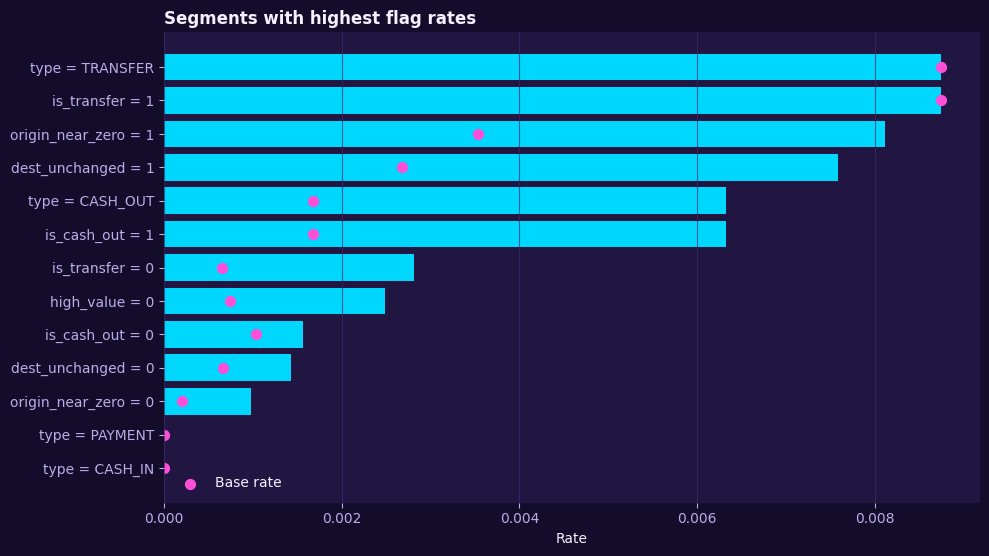

In [6]:

display(Markdown("## Subgroup threshold-sensitivity audit"))

test_index = X_test_enc.index if hasattr(X_test_enc, 'index') else pd.Index(range(len(y_test_enc)))
# Encoded data produced by HUG-IML keeps original columns and index in current library versions.
raw_test = X.loc[test_index].copy()
audit_frame = raw_test.copy()
audit_frame['_actual'] = np.asarray(y_test_enc).astype(int)
audit_frame['_score'] = y_score
audit_frame['_flag'] = (audit_frame['_score'] >= operating_threshold).astype(int)

subgroup_records = []
for col in GROUP_COLUMNS:
    if col not in audit_frame.columns:
        continue
    vc = audit_frame[col].value_counts(dropna=False)
    levels = vc[vc >= max(20, 0.01 * len(audit_frame))].index.tolist()
    for level in levels[:12]:
        g = audit_frame[audit_frame[col].eq(level)]
        if len(g) < 20:
            continue
        y_g = g['_actual'].astype(int).to_numpy()
        flag_g = g['_flag'].astype(int).to_numpy()
        if len(np.unique(y_g)) < 2:
            auc_g = np.nan
        else:
            auc_g = roc_auc_score(y_g, g['_score'])
        tn_g, fp_g, fn_g, tp_g = confusion_matrix(y_g, flag_g, labels=[0,1]).ravel()
        subgroup_records.append({
            'feature': col,
            'segment': str(level),
            'n': len(g),
            'base_rate': y_g.mean(),
            'flag_rate': flag_g.mean(),
            'auc': auc_g,
            'precision': tp_g / max(tp_g + fp_g, 1),
            'recall': tp_g / max(tp_g + fn_g, 1),
            'false_positive_rate': fp_g / max(fp_g + tn_g, 1),
        })

subgroup_audit = pd.DataFrame(subgroup_records)
if len(subgroup_audit):
    display(subgroup_audit.sort_values(['feature','n'], ascending=[True, False]).round(4))
    plot_audit = subgroup_audit.sort_values('flag_rate', ascending=False).head(14).copy()
    plot_audit['segment_label'] = plot_audit['feature'] + ' = ' + plot_audit['segment']
    fig, ax = plt.subplots(figsize=(10, max(4.8, 0.32 * len(plot_audit) + 1.5)))
    ax.barh(plot_audit['segment_label'], plot_audit['flag_rate'], color=THEME['accent'])
    ax.scatter(plot_audit['base_rate'], plot_audit['segment_label'], color=THEME['accent2'], s=50, label='Base rate')
    ax.invert_yaxis()
    ax.set_title('Segments with highest flag rates', loc='left')
    ax.set_xlabel('Rate')
    ax.grid(axis='x', color=THEME['grid'], alpha=0.7)
    ax.legend(frameon=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("No subgroup columns with sufficient holdout support were available for this audit view."))


## Score concentration and review prioritization

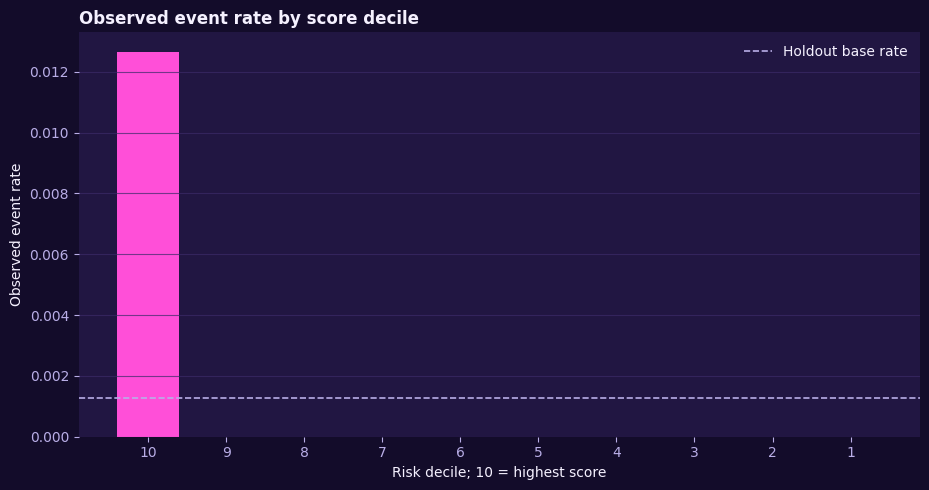

,risk_decile,n,event_rate,avg_score,event_capture,event_capture_share
9,10,1500,0.0127,0.0149,19,1.0
8,9,1500,0.0000,0.0005,0,0.0
7,8,1500,0.0000,0.0002,0,0.0
6,7,1500,0.0000,0.0001,0,0.0
5,6,1500,0.0000,0.0001,0,0.0
4,5,1500,0.0000,0.0001,0,0.0
3,4,1500,0.0000,0.0000,0,0.0
2,3,1500,0.0000,0.0000,0,0.0
1,2,1500,0.0000,0.0000,0,0.0
0,1,1500,0.0000,0.0000,0,0.0


In [7]:

display(Markdown("## Score concentration and review prioritization"))

score_table = pd.DataFrame({'actual': np.asarray(y_test_enc).astype(int), 'score': y_score})
score_table['risk_decile'] = pd.qcut(score_table['score'].rank(method='first'), 10, labels=False) + 1
decile = score_table.groupby('risk_decile').agg(
    n=('actual','size'),
    event_rate=('actual','mean'),
    avg_score=('score','mean'),
    event_capture=('actual','sum')
).reset_index()
decile['event_capture_share'] = decile['event_capture'] / max(decile['event_capture'].sum(), 1)
decile = decile.sort_values('risk_decile', ascending=False)

fig, ax = plt.subplots(figsize=(9.4, 5.0))
ax.bar(decile['risk_decile'].astype(str), decile['event_rate'], color=THEME['accent2'])
ax.axhline(score_table['actual'].mean(), linestyle='--', color=THEME['muted'], linewidth=1.2, label='Holdout base rate')
ax.set_title('Observed event rate by score decile', loc='left')
ax.set_xlabel('Risk decile; 10 = highest score')
ax.set_ylabel('Observed event rate')
ax.grid(axis='y', color=THEME['grid'], alpha=0.7)
ax.legend(frameon=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.tight_layout()
plt.show()

display(decile.round(4))

top_decile_rate = float(decile.loc[decile['risk_decile'].eq(10), 'event_rate'].iloc[0])
base_rate = float(score_table['actual'].mean())
lift = top_decile_rate / max(base_rate, 1e-12)
display(HTML(f'''
<div class="callout">
<b>Prioritization insight.</b> The highest score decile has an observed event rate of <b>{top_decile_rate:.2%}</b>, 
which is <b>{lift:.1f}×</b> the holdout base rate of <b>{base_rate:.2%}</b>. This supports a queue-based review strategy when operational capacity is limited.
</div>
'''))


In [ ]:

display(Markdown("## Exported governance artifacts"))

artifact_prefix = 'nb06_mobile_money_fraud'
patterns.to_csv(f'{artifact_prefix}_pattern_inventory.csv', index=False)
threshold_table.to_csv(f'{artifact_prefix}_threshold_grid.csv', index=False)
if 'subgroup_audit' in globals() and len(subgroup_audit):
    subgroup_audit.to_csv(f'{artifact_prefix}_subgroup_audit.csv', index=False)
feature_rows.to_csv(f'{artifact_prefix}_feature_register.csv', index=False)

display(Markdown(f"""
Generated governance artifacts:

- `{artifact_prefix}_pattern_inventory.csv`
- `{artifact_prefix}_threshold_grid.csv`
- `{artifact_prefix}_feature_register.csv`
- `{artifact_prefix}_subgroup_audit.csv` when subgroup audit rows are available
"""))


The completed workflow provides a transparent HUG-IML classifier view for mobile money fraud detection. The final notebook combines predictive metrics with interpretable pattern evidence, threshold governance, subgroup monitoring, and exportable audit tables.

The strongest governance value comes from the combination of:

- ranked HUG pattern coefficients that can be inspected as decision evidence,
- metadata-aligned feature documentation,
- threshold-specific operating behavior rather than a single static accuracy number,
- subgroup views that highlight where flag rates, recall, or false-positive rates differ materially.